# Практичне завдання 1: Лінійна регресія, оптимізація та статистичний аналіз

**Датасет:** Ames Housing (Dean De Cock, 2930 спостережень, 80 ознак)
**Цільова змінна:** `SalePrice`

| Етап | Зміст |
|---|---|
| 1 | EDA, відбір ознак, спліт, кодування, масштабування |
| 2 | Реалізація лінійної регресії на numpy |
| 3 | Batch GD, SGD, Mini-batch GD |
| 4 | Коефіцієнт детермінації R² |
| 5 | Перевірка статистичних припущень |
| 6 | Експеримент В: Ridge Regression (L2-регуляризація) |

### Технічні умови

Модель, функція втрат, градієнти та всі алгоритми оптимізації реалізовані **самостійно засобами
numpy**. Цикли `for` для обчислення Cost Function та градієнтів не використовуються — лише
векторизація та матричні операції. Бібліотека `scikit-learn` застосовується виключно для
допоміжних операцій підготовки даних (спліт, one-hot кодування, стандартизація), що умовами
завдання не заборонено.

---
# Етап 1. Дослідження даних, відбір ознак та попередня обробка

### Зауваження щодо порядку виконання

У формулюванні завдання відбір ознак стоїть пунктом 2, а розбиття вибірки — пунктом 3. Проте там
же зазначено, що відбір ознак **не повинен використовувати тестову вибірку**.

Ці дві вимоги суперечать одна одній, якщо виконувати їх буквально: щоб порахувати кореляції лише
на Train, Train має вже існувати. Тому фактичний порядок у роботі такий:

**спліт → відбір ознак на Train → кодування та масштабування з параметрами з Train.**

Це єдиний порядок, за якого гарантовано відсутній витік даних.

## 1.1 Первинний аналіз даних

(2930, 80)
str        43
int64      26
float64    11
Name: count, dtype: int64
PoolQC          2917
MiscFeature     2824
Alley           2732
Fence           2358
MasVnrType      1775
FireplaceQu     1422
LotFrontage      490
GarageQual       159
GarageCond       159
GarageYrBlt      159
GarageFinish     159
GarageType       157
BsmtExposure      83
BsmtFinType2      81
BsmtCond          80
BsmtQual          80
BsmtFinType1      80
MasVnrArea        23
BsmtFullBath       2
BsmtHalfBath       2
BsmtFinSF1         1
BsmtFinSF2         1
Electrical         1
TotalBsmtSF        1
BsmtUnfSF          1
GarageArea         1
GarageCars         1
dtype: int64


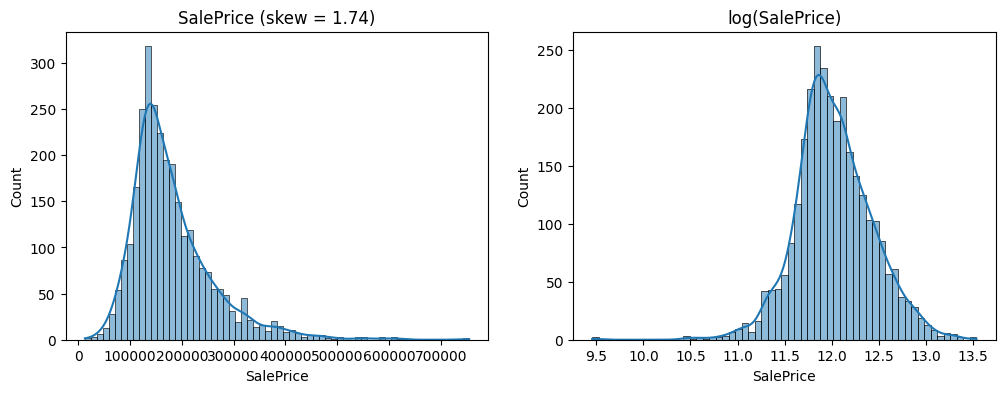

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')

print(df.shape)
print(df.dtypes.value_counts())

# пропуски
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print(na)

# цільова змінна
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=ax[0])
ax[0].set_title(f"SalePrice (skew = {df['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=ax[1])
ax[1].set_title('log(SalePrice)')
plt.show()

**Про пропущені значення.** Значна частина пропусків не є втраченими даними. У документації до
датасету `NA` для ознак `Alley`, `PoolQC`, `Fence`, `FireplaceQu`, `Garage*`, `Bsmt*` означає
**відсутність самого об'єкта** (немає провулку, басейну, каміна, гаража, підвалу), а не невідоме
значення. Це визначає стратегію заповнення: для порядкових ознак якості логічним кодом
відсутності є 0, а не медіана.

### Рішення про логарифмування цільової змінної

Розподіл `SalePrice` має виражену правосторонню асиметрію (skew ≈ 1.74): більшість будинків
коштує 130–215 тис. доларів, але присутній довгий хвіст дорогої нерухомості до 755 тис.

Для лінійної регресії це проблема з двох причин:

1. **Гетероскедастичність.** Помилка прогнозу для будинку за 700 тис. природно більша за помилку
   для будинку за 100 тис. в абсолютних величинах. MSE був би надмірно зосереджений на дорогих
   об'єктах.
2. **Ненормальність залишків**, що робить статистичні висновки про коефіцієнти ненадійними.

Логарифмування знижує асиметрію до 0.12 і переводить задачу в **мультиплікативну шкалу**: модель
прогнозує відсоткову, а не абсолютну зміну ціни. Це відповідає економічній природі задачі —
додатковий квадратний метр підвищує ціну на певний **відсоток**, а не на фіксовану суму.

Надалі навчання ведеться на `y = log1p(SalePrice)`; на Етапі 4 якість додатково оцінюється
у вихідній доларовій шкалі.

## 1.2 Розбиття вибірки (виконується першим)

In [7]:
from sklearn.model_selection import train_test_split

y = np.log1p(df['SalePrice'])
X = df.drop(columns=['SalePrice'])

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

print(X_tr.shape, X_val.shape, X_te.shape)  # 60% / 20% / 20%

(1758, 79) (586, 79) (586, 79)


## 1.3 Відбір ознак

Усі статистики для відбору обчислюються **виключно на Train**.

OverallQual     0.813623
GrLivArea       0.689894
GarageCars      0.666580
GarageArea      0.636707
TotalBsmtSF     0.631437
1stFlrSF        0.600993
YearBuilt       0.593245
FullBath        0.572085
YearRemodAdd    0.559378
GarageYrBlt     0.558601
TotRmsAbvGrd    0.484634
Fireplaces      0.480506
MasVnrArea      0.443722
BsmtFinSF1      0.409627
LotFrontage     0.349152
WoodDeckSF      0.343457
HalfBath        0.311911
BsmtFullBath    0.293405
OpenPorchSF     0.276021
2ndFlrSF        0.271378
Name: SalePrice, dtype: float64


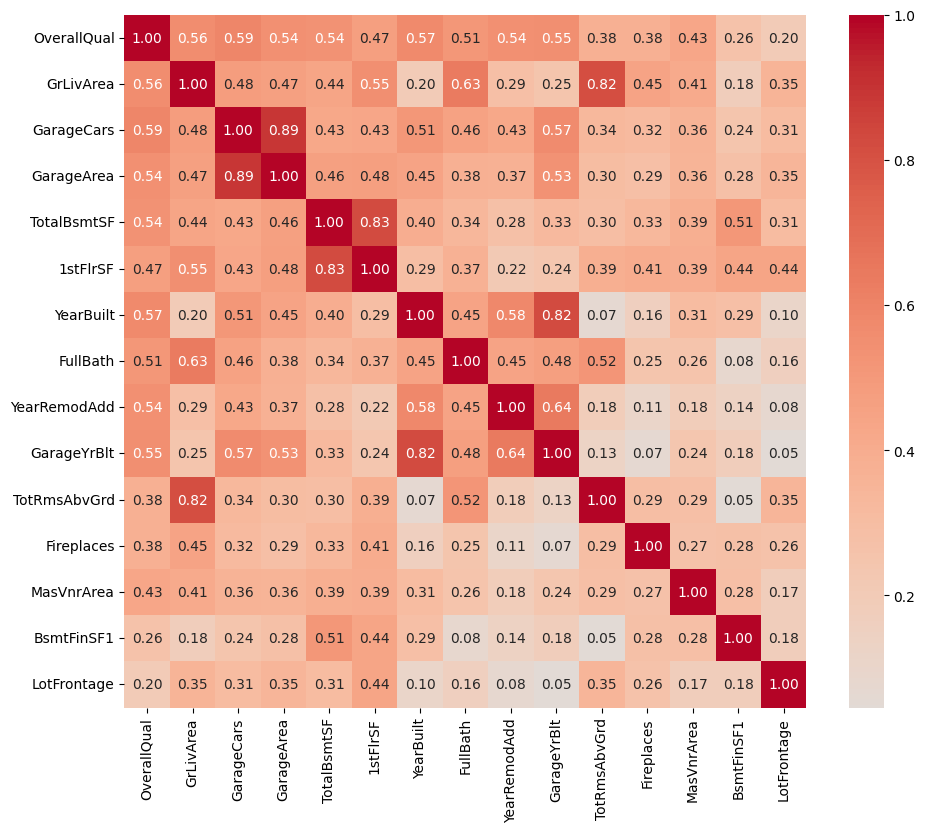

In [5]:
num_cols = X_tr.select_dtypes(include=[np.number]).columns
corr = X_tr[num_cols].join(y_tr).corr()['SalePrice'].drop('SalePrice')
print(corr.abs().sort_values(ascending=False).head(20))

# кореляції МІЖ ознаками — шукаємо мультиколінеарність
top = corr.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(11, 9))
sns.heatmap(X_tr[top].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

### Обґрунтування вибору ознак

**Критерій включення:** кореляція з цільовою змінною за модулем вище ~0.3 плюс змістовна
інтерпретованість ознаки в предметній області.

**Числові ознаки (12):** `OverallQual`, `GrLivArea`, `TotalBsmtSF`, `GarageCars`, `GarageArea`,
`YearBuilt`, `YearRemodAdd`, `FullBath`, `TotRmsAbvGrd`, `Fireplaces`, `LotArea`, `MasVnrArea`.

**Порядкові ознаки (3):** `KitchenQual`, `ExterQual`, `BsmtQual` — оцінки якості за шкалою
Po < Fa < TA < Gd < Ex. Мають природний порядок, тому кодуються числами 1–5, а не one-hot:
це зберігає інформацію про впорядкованість і дає 1 колонку замість 5.

**Номінальні ознаки (3):** `Neighborhood`, `BldgType`, `HouseStyle` — категорії без природного
порядку, кодуються one-hot. `Neighborhood` — одна з найінформативніших ознак у датасеті,
попри високу кардинальність (28 категорій).

### Свідоме збереження корельованих пар

На тепловій карті помітні три сильні зв'язки між самими ознаками:

| Пара | Кореляція | Природа зв'язку |
|---|---|---|
| `GarageCars` ↔ `GarageArea` | ≈ 0.89 | дві міри одного й того ж — розміру гаража |
| `TotRmsAbvGrd` ↔ `GrLivArea` | ≈ 0.81 | більша площа → більше кімнат |
| `1stFlrSF` ↔ `TotalBsmtSF` | ≈ 0.80 | підвал зазвичай повторює контур першого поверху |

Стандартна практика вимагала б видалити по одній ознаці з кожної пари. **У цій роботі перші дві
пари залишені свідомо** — вони необхідні для демонстрації мультиколінеарності на Етапі 5 та
ефекту L2-регуляризації на Етапі 6. Ознака `1stFlrSF` до моделі не включена.

In [8]:
NUM = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'GarageArea', 'YearBuilt', 'YearRemodAdd', 'FullBath', 'TotRmsAbvGrd','Fireplaces', 'LotArea', 'MasVnrArea']
ORD = ['KitchenQual', 'ExterQual', 'BsmtQual']   # порядкові
CAT = ['Neighborhood', 'BldgType', 'HouseStyle'] # номінальні

## 1.4 Кодування категорій, заповнення пропусків та масштабування

### Обґрунтування вибору методу кодування

**One-Hot Encoding** застосовано до номінальних ознак. Вони не мають порядку, тому будь-яке
присвоєння їм чисел створило б фіктивне відношення «більше/менше»: модель вирішила б, що
район №5 удвічі «більший» за район №2, що позбавлено сенсу.

Використано `drop='first'` — видалення однієї базової категорії. Без цього сума всіх dummy-колонок
однієї ознаки тотожно дорівнює стовпцю одиниць, тобто виникає точна лінійна залежність із вільним
членом (**dummy variable trap**). Наслідок — вироджена матриця $X^TX$, нескінченний VIF і
нестабільність градієнтного спуску.

**Ordinal Encoding** застосовано до ознак якості: `Po→1, Fa→2, TA→3, Gd→4, Ex→5`. Порядок тут
об'єктивний, тому кодування зберігає реальну інформацію і суттєво економить розмірність.

**Target Encoding** свідомо **не використано**. Він кодує категорію середнім значенням цілі, що є
прямим джерелом витоку даних: інформація про `y` потрапляє в ознаки. Коректне застосування
вимагає вкладеної крос-валідації та згладжування, що надмірно ускладнило б роботу без виграшу
для поставленої задачі.

**Про структуру функції `prepare()`.** Параметр `fit=True` обчислює всі статистики (медіани,
перелік категорій, $\mu$ і $\sigma$) і зберігає їх у `state`; при `fit=False` вони лише
застосовуються. Це технічна гарантія відсутності витоку: параметри фізично обчислюються один раз
і лише на Train.

In [9]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

QUAL = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

def prepare(X, fit=False, state={}):
    Xn = X[NUM].copy()
    if fit:
        state['medians'] = Xn.median()          # медіани ТІЛЬКИ з train
    Xn = Xn.fillna(state['medians'])

    Xo = X[ORD].apply(lambda s: s.map(QUAL)).fillna(0)  # NaN = об'єкта немає

    if fit:
        state['ohe'] = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
        state['ohe'].fit(X[CAT].fillna('NA'))
    Xc = state['ohe'].transform(X[CAT].fillna('NA'))

    out = np.hstack([Xn.values, Xo.values, Xc])

    if fit:
        state['scaler'] = StandardScaler().fit(out)   # μ, σ ТІЛЬКИ з train
    return state['scaler'].transform(out), state

state = {}
Xtr, state = prepare(X_tr, fit=True, state=state)
Xval, _ = prepare(X_val, state=state)
Xte,  _ = prepare(X_te,  state=state)

ytr, yval, yte = y_tr.values, y_val.values, y_te.values
print(Xtr.shape, Xval.shape, Xte.shape)

(1758, 53) (586, 53) (586, 53)


## Відповіді на теоретичні питання Етапу 1

### Питання 1. Чому спліт має виконуватися до масштабування, кодування та інших операцій, що навчаються на даних? Що таке Data Leakage?

Будь-яка операція підготовки, що «навчається» на даних, витягує з них узагальнену статистику:

- `StandardScaler` — середнє $\mu$ та стандартне відхилення $\sigma$;
- заповнення пропусків — медіану або середнє;
- `OneHotEncoder` — повний перелік наявних категорій;
- `SelectKBest`, RFE, Lasso — значення статистичних тестів і ваги.

Якщо ці параметри обчислити на всьому датасеті, у них потрапить інформація з валідаційної та
тестової вибірок. Модель отримає непрямий доступ до даних, яких вона не мала б бачити.

**Data Leakage (витік даних)** — це ситуація, коли в процес навчання моделі потрапляє інформація,
недоступна на момент реального прогнозування.

Наслідки:

1. Метрики на тесті виявляються **завищеними** — модель виглядає кращою, ніж є насправді.
2. Тестова вибірка перестає бути незалежною оцінкою: щойно вона хоч якось вплинула на підготовку,
   вона більше не імітує «нові, ніколи не бачені дані».
3. У реальній експлуатації якість моделі виявляється суттєво нижчою за очікувану.

Масштаб витоку значення не має: навіть якщо $\mu$ і $\sigma$, пораховані на всьому датасеті,
відрізняються від Train-версії в третьому знаку, сам принцип незалежності тесту вже порушено.

### Питання 2. Як обробляти категорії, що з'являться на валідації або тесті, але яких не було в Train?

Застосовано `handle_unknown='ignore'` у `OneHotEncoder`: невідома категорія кодується рядком із
самих нулів. Модель інтерпретує її як «жодна з відомих категорій» і спирається на решту ознак —
прогноз буде менш точним, але коректним і без помилки виконання.

Альтернативні стратегії:

| Метод | Підхід |
|---|---|
| Групування рідкісних | Звести категорії з частотою нижче порогу в спільну `'Other'` ще на Train — тоді нове значення природно потрапляє до вже відомої групи |
| Ordinal Encoding | Присвоїти невідомій категорії нейтральний код (0 або медіанний ранг) |
| Target Encoding | Підставити глобальне середнє цілі, обчислене на Train |

Чого робити **не можна**: аварійно завершувати роботу або перенавчати енкодер на валідації чи
тесті — останнє є прямим витоком даних.

У нашому випадку ризик реальний саме для `Neighborhood` (28 категорій, деякі рідкісні), тоді як
для `BldgType` і `HouseStyle` усі категорії гарантовано присутні в Train.

---
# Етап 2. Реалізація лінійної регресії засобами numpy

Модель має вигляд:

$$\hat{y} = Xw + b$$

де $X \in \mathbb{R}^{m \times n}$ — матриця ознак, $w \in \mathbb{R}^{n}$ — вектор ваг,
$b \in \mathbb{R}$ — вільний член.

**Функція втрат (MSE):**

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

**Градієнти.** Диференціюємо за $w_j$, враховуючи, що
$\frac{\partial \hat{y}^{(i)}}{\partial w_j} = X_{ij}$:

$$\frac{\partial J}{\partial w_j} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)X_{ij}
\quad\Longrightarrow\quad
\nabla_w J = \frac{2}{m}X^T(\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)$$

Перехід від суми з індексами до матричного добутку $X^T(\hat{y}-y)$ і є векторизацією: наївна
реалізація потребувала б двох вкладених циклів, тоді як матричний добуток виконується одним
викликом оптимізованої бібліотеки BLAS.

**Деталі реалізації.** Вираз `err @ err` — скалярний добуток вектора помилок сам на себе, тобто
сума квадратів; працює швидше за `np.sum(err ** 2)`, оскільки не створює проміжного масиву.

Множник $2/m$ походить безпосередньо з похідної квадрата. Частина джерел визначає
$J = \frac{1}{2m}\sum(\cdot)^2$, щоб двійка скоротилась; обидва варіанти коректні, різниця лише
в масштабі learning rate. Тут залишено «чесний» MSE відповідно до умови завдання.

Вільний член $b$ **не регуляризується**: штраф має обмежувати нахили, а не забороняти моделі
зміщувати прогноз до середнього рівня цін.

In [10]:
import numpy as np


class LinearRegressionNP:
    """
    Лінійна регресія: y_hat = X @ w + b
    Усі обчислення векторизовані, циклів for немає.
    l2 — параметр Ridge-регуляризації (знадобиться на Етапі 6, за замовчуванням вимкнено).
    """

    def __init__(self, n_features, l2=0.0, seed=42):
        rng = np.random.default_rng(seed)
        # мала випадкова ініціалізація; нулі теж працюють, але так видно збіжність
        self.w = rng.normal(0, 0.01, size=n_features)
        self.b = 0.0
        self.l2 = l2

    # --- прогноз -------------------------------------------------------
    def predict(self, X):
        return X @ self.w + self.b

    # --- функція втрат -------------------------------------------------
    def cost(self, X, y):
        m = X.shape[0]
        err = self.predict(X) - y
        mse = (err @ err) / m                      # еквівалент np.mean(err**2)
        reg = self.l2 * (self.w @ self.w) / (2 * m)
        return mse + reg

    # --- градієнти -----------------------------------------------------
    def gradients(self, X, y):
        m = X.shape[0]
        err = self.predict(X) - y                  # (m,)
        dw = (2 / m) * (X.T @ err) + (self.l2 / m) * self.w
        db = (2 / m) * err.sum()
        return dw, db

    # --- крок оновлення ------------------------------------------------
    def step(self, dw, db, lr):
        self.w -= lr * dw
        self.b -= lr * db

## 2.1 Перевірка коректності градієнтів (gradient checking)

Аналітичний градієнт порівнюється з чисельною центральною різницею:

$$\frac{\partial J}{\partial w_j} \approx \frac{J(w_j + \varepsilon) - J(w_j - \varepsilon)}{2\varepsilon}$$

Це стандартна діагностична процедура, що виявляє помилки у знаках і множниках.

Цикл `for` у цій комірці не суперечить умові завдання: заборона стосується обчислення Cost
Function і градієнтів **під час навчання**, тоді як це одноразова діагностика.

In [11]:
def grad_check(X, y, eps=1e-6):
    model = LinearRegressionNP(X.shape[1])
    dw, db = model.gradients(X, y)

    # чисельна похідна по кількох випадкових координатах w
    idx = np.random.default_rng(0).choice(X.shape[1], size=5, replace=False)
    num = []
    for j in idx:                      # цикл ЛИШЕ для перевірки, не для навчання
        orig = model.w[j]
        model.w[j] = orig + eps; plus = model.cost(X, y)
        model.w[j] = orig - eps; minus = model.cost(X, y)
        model.w[j] = orig
        num.append((plus - minus) / (2 * eps))

    print('аналітичні:', np.round(dw[idx], 6))
    print('чисельні:  ', np.round(num, 6))
    print('макс. різниця:', np.max(np.abs(dw[idx] - num)))

grad_check(Xtr[:200], ytr[:200])

аналітичні: [-2.206061  0.572863  0.349721  1.296962  0.290291]
чисельні:   [-2.206061  0.572863  0.349721  1.296962  0.29029 ]
макс. різниця: 1.3880201044091933e-08


Розбіжність порядку $10^{-8}$ відповідає похибці округлення `float64` при центральній різниці
з $\varepsilon = 10^{-6}$. Градієнти реалізовано коректно.

## 2.2 Бонус: Normal Equation та її обмеження

Додамо до матриці $X$ стовпець одиниць, щоб вільний член увійшов у вектор параметрів. Функція
втрат у матричній формі:

$$J(w) = \frac{1}{m}(Xw - y)^T(Xw - y)$$

Розкриваємо дужки, враховуючи $w^TX^Ty = y^TXw$ (скаляр дорівнює своєму транспонованому):

$$J(w) = \frac{1}{m}\left(w^TX^TXw - 2w^TX^Ty + y^Ty\right)$$

Градієнт за $w$ і умова стаціонарності:

$$\nabla_w J = \frac{2}{m}\left(X^TXw - X^Ty\right) = 0$$

Звідси **нормальні рівняння** $X^TXw = X^Ty$ і, за умови оборотності $X^TX$:

$$\boxed{\;w = (X^TX)^{-1}X^Ty\;}$$

Оскільки $J$ опукла (матриця Гессе $\frac{2}{m}X^TX$ невід'ємно визначена), знайдена стаціонарна
точка є глобальним мінімумом.

### Обмеження методу

**1. Обчислювальна складність.** Обернення матриці $n \times n$ потребує $O(n^3)$ операцій.
За кількох десятків ознак це миттєво, але при десятках тисяч (текстові дані, one-hot ознаки
високої кардинальності) метод стає непридатним. Градієнтний спуск масштабується лінійно за $n$.

**2. Вимога оборотності.** Матриця $X^TX$ вироджена, якщо між ознаками існує точна лінійна
залежність. Саме цей випадок ми запобігли параметром `drop='first'`: без нього сума dummy-колонок
дорівнювала б стовпцю одиниць.

За **майже** лінійної залежності (мультиколінеарність) матриця погано обумовлена: її число
обумовленості велике, обернення чисельно нестабільне, а оцінки ваг роздуваються й різко
змінюються від мікроскопічних збурень у даних. Це прямо мотивує Ridge-регресію, де додавання
$\lambda I$ гарантує оборотність: $w = (X^TX + \lambda I)^{-1}X^Ty$.

**3. Прив'язка до MSE.** Замкнений розв'язок існує лише для квадратичної функції втрат.
Для MAE, Huber loss чи логістичної регресії аналітичного розв'язку немає — градієнтні методи
універсальні.

**4. Вимоги до пам'яті.** Метод потребує одночасного доступу до всього датасету, тоді як SGD
здатний навчатися потоково, обробляючи дані порціями.

---
# Етап 3. Градієнтний спуск: три варіанти оптимізації

Три методи відрізняються **лише кількістю прикладів, на яких обчислюється градієнт перед кроком**:

| Метод | Розмір батчу | Кроків за епоху (m = 1758) |
|---|---|---|
| Batch GD | $m$ (усі дані) | 1 |
| SGD | 1 | 1758 |
| Mini-batch GD | $B = 32$ | 55 |

Тому реалізовано одну універсальну функцію навчання, що параметризується розміром батчу.

**Перемішування даних** (`rng.permutation`) обов'язкове для SGD і Mini-batch. Без нього модель
щоепохи бачить приклади в однаковому порядку, що може призводити до періодичних коливань.
У Ames Housing дані впорядковані не випадково, тому це має практичне значення.

**Зауваження щодо коректності порівняння.** За одну епоху Batch GD виконує один крок оновлення,
а SGD — 1758. Порівняння «за епохами» тому не є порівнянням за обчислювальними витратами.

**Щодо циклів.** Зовнішній цикл по епохах і внутрішній по батчах не суперечать умові завдання:
заборона стосується обчислення Cost Function і градієнтів, які повністю векторизовані
в методах `cost()` та `gradients()`.

In [12]:
def train(X, y, batch_size=None, lr=0.01, epochs=200, l2=0.0, tol=1e-7, patience=5, seed=42, X_val=None, y_val=None):
    """
    batch_size = None -> Batch GD (увесь датасет)
    batch_size = 1    -> SGD
    batch_size = B    -> Mini-batch GD

    Критерій зупинки: |J_prev - J| < tol протягом patience епох поспіль.
    """
    m, n = X.shape
    model = LinearRegressionNP(n, l2=l2, seed=seed)
    rng = np.random.default_rng(seed)
    bs = m if batch_size is None else batch_size

    history, val_history = [], []
    stale = 0

    for ep in range(epochs):
        idx = rng.permutation(m)            # перемішування кожної епохи

        # проходимо датасет батчами
        for start in range(0, m, bs):
            part = idx[start:start + bs]
            dw, db = model.gradients(X[part], y[part])
            model.step(dw, db, lr)

        J = model.cost(X, y)                # повна вартість у кінці епохи
        history.append(J)
        if X_val is not None:
            val_history.append(model.cost(X_val, y_val))

        if not np.isfinite(J):              # розбіжність — знадобиться в Експерименті Б
            print(f'  розбіжність на епосі {ep}')
            break

        if ep > 0 and abs(history[-2] - J) < tol:
            stale += 1
            if stale >= patience:
                print(f'  зупинка на епосі {ep} (J = {J:.6f})')
                break
        else:
            stale = 0

    return model, np.array(history), np.array(val_history)

## 3.1 Підбір Learning Rate

Для кожного методу перевіряємо діапазон значень $\alpha$ і обираємо те, що дає найнижче $J$
без ознак нестабільності.

In [13]:
for lr in [0.5, 0.1, 0.05, 0.01, 0.001]:
    _, h, _ = train(Xtr, ytr, batch_size=None, lr=lr, epochs=100)
    print(f'Batch,      lr={lr:<6} -> J = {h[-1]:.5f}')

for lr in [0.05, 0.01, 0.005, 0.001, 0.0005]:
    _, h, _ = train(Xtr, ytr, batch_size=1, lr=lr, epochs=20)
    print(f'SGD,        lr={lr:<6} -> J = {h[-1]:.5f}')

for lr in [0.1, 0.05, 0.01, 0.005, 0.001]:
    _, h, _ = train(Xtr, ytr, batch_size=32, lr=lr, epochs=50)
    print(f'Mini-batch, lr={lr:<6} -> J = {h[-1]:.5f}')

Batch,      lr=0.5    -> J = 740926183270264579557388590765842122250870162625355607131361257155311129028345458882319831453018664195919439149909165677877584086407094464808729109110074688667648.00000
Batch,      lr=0.1    -> J = 0.02092
Batch,      lr=0.05   -> J = 0.02104
Batch,      lr=0.01   -> J = 2.56125
Batch,      lr=0.001  -> J = 96.76235
  розбіжність на епосі 1
SGD,        lr=0.05   -> J = nan


C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:26: RuntimeWarning: overflow encountered in matmul
  mse = (err @ err) / m                      # еквівалент np.mean(err**2)
C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:27: RuntimeWarning: overflow encountered in matmul
  reg = self.l2 * (self.w @ self.w) / (2 * m)
C:\Users\uzimi\AppData\Local\Temp\ipykernel_10340\767909073.py:27: RuntimeWarning: invalid value encountered in scalar multiply
  reg = self.l2 * (self.w @ self.w) / (2 * m)


SGD,        lr=0.01   -> J = 1872367266387899498555992458861523859935602344862315208507886569793508673602856368416851233143787135658488135563569392673374333587595786721665605593533415079284657618816294971429093376.00000
SGD,        lr=0.005  -> J = 186647947784359505898611491903177814098245367436843699021947622268259237215475901399040.00000
SGD,        lr=0.001  -> J = 1279632023099824.00000
SGD,        lr=0.0005 -> J = 0.02113
Mini-batch, lr=0.1    -> J = 216777227787288838556407778416124930601733523656474956454122593653575092510486190399833596841439245937275832158186045015905533952.00000
Mini-batch, lr=0.05   -> J = 29554115809986157487759587312733209827944492822615861722517340160.00000
Mini-batch, lr=0.01   -> J = 0.02098
Mini-batch, lr=0.005  -> J = 0.02092
Mini-batch, lr=0.001  -> J = 0.02364


In [16]:
for lr in [0.0005, 0.0002, 0.0001]:
    _, h, _ = train(Xtr, ytr, batch_size=1, lr=lr, epochs=30)
    print(f'SGD, lr={lr:<7} -> J = {h[-1]:.5f}')

SGD, lr=0.0005  -> J = 0.02105
SGD, lr=0.0002  -> J = 0.02094
SGD, lr=0.0001  -> J = 0.02103


### Результати підбору

| Метод | Обраний $\alpha$ | Межа розбіжності |
|---|---|---|
| Batch GD | **0.1** | $\alpha = 0.5$ — $J \to 10^{158}$ |
| SGD | **0.0002** | $\alpha = 0.001$ — $J \approx 10^{15}$ |
| Mini-batch (B=32) | **0.005** | $\alpha = 0.05$ — $J \approx 10^{64}$ |

**Різниця в допустимому $\alpha$ між Batch GD і SGD становить 500 разів** — це кількісна
відповідь на питання про різну чутливість методів до learning rate.

Окремо слід розрізняти два різні явища:

- $\alpha = 0.001$ для Batch GD дає $J = 96.76$ — це **не розбіжність**, а надто повільна
  збіжність. Початкова вартість становить приблизно $\overline{y^2} \approx 145$ (оскільки $b$
  стартує з нуля, а $y \approx 12$), тобто за 100 епох модель майже не зрушила з місця.
- $\alpha = 0.5$ для Batch GD дає $J \approx 10^{158}$ — це справжня розбіжність.

## 3.2 Навчання трьох моделей та порівняльний графік збіжності

На лінійній шкалі всі три криві зливаються біля нуля вже після ~20 епох, тому додано логарифмічну
шкалу з обмеженням по осі X — вона показує початкову фазу, де й проявляється різниця між методами.

  зупинка на епосі 168 (J = 0.020901)


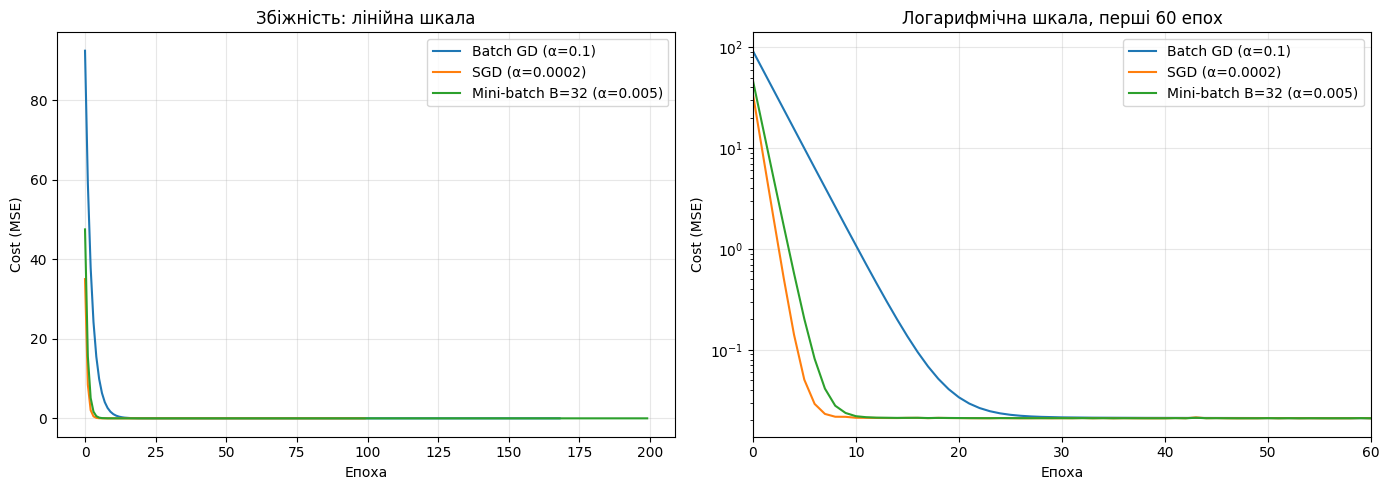

In [17]:
LR_BATCH, LR_SGD, LR_MINI = 0.1, 0.0002, 0.005

m_batch, h_batch, v_batch = train(Xtr, ytr, None, LR_BATCH, 500, X_val=Xval, y_val=yval)
m_sgd,   h_sgd,   v_sgd   = train(Xtr, ytr, 1,    LR_SGD,   100, X_val=Xval, y_val=yval)
m_mini,  h_mini,  v_mini  = train(Xtr, ytr, 32,   LR_MINI,  200, X_val=Xval, y_val=yval)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for h, name in [(h_batch, f'Batch GD (α={LR_BATCH})'),
                (h_sgd,   f'SGD (α={LR_SGD})'),
                (h_mini,  f'Mini-batch B=32 (α={LR_MINI})')]:
    ax[0].plot(h, label=name)
    ax[1].plot(h, label=name)

ax[0].set(xlabel='Епоха', ylabel='Cost (MSE)', title='Збіжність: лінійна шкала')
ax[1].set(xlabel='Епоха', ylabel='Cost (MSE)', yscale='log', xlim=(0, 60), title='Логарифмічна шкала, перші 60 епох')
for a in ax:
    a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3.3 Поведінка SGD в околі мінімуму

Коливання стохастичного градієнтного спуску не видно на графіку по епохах, оскільки кожна точка
там — результат усереднення 1758 кроків. Тому вимірюємо Cost **після кожного окремого кроку**,
стартуючи з уже навченої моделі, тобто безпосередньо в околі мінімуму. Для порівняння взято два
значення $\alpha$.

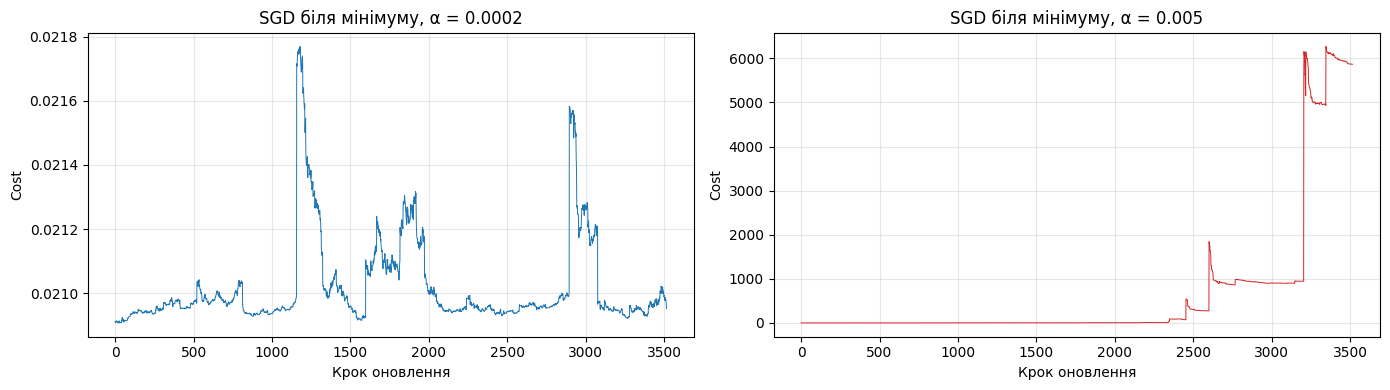

α=0.0002: середнє 0.02102, розмах 0.00086
α=0.005:  середнє 677.43,  розмах 6270.65


In [20]:
import copy

def sgd_trace(model, lr, epochs, seed=0):
    model = copy.deepcopy(model)
    rng = np.random.default_rng(seed)
    trace = []
    for ep in range(epochs):
        for i in rng.permutation(len(Xtr)):
            dw, db = model.gradients(Xtr[i:i+1], ytr[i:i+1])
            model.step(dw, db, lr)
            trace.append(model.cost(Xtr, ytr))
    return np.array(trace)

# m_sgd уже навчена — стартуємо з околу мінімуму
t_small = sgd_trace(m_sgd, lr=0.0002, epochs=2)
t_big   = sgd_trace(m_sgd, lr=0.005,  epochs=2)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(t_small, lw=0.7)
ax[0].set_title('SGD біля мінімуму, α = 0.0002')
ax[1].plot(t_big, lw=0.7, color='tab:red')
ax[1].set_title('SGD біля мінімуму, α = 0.005')
for a in ax:
    a.set(xlabel='Крок оновлення', ylabel='Cost'); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'α=0.0002: середнє {t_small.mean():.5f}, розмах {np.ptp(t_small):.5f}')
print(f'α=0.005:  середнє {t_big.mean():.2f},  розмах {np.ptp(t_big):.2f}')

---
## Аналіз поведінки трьох методів

### Який метод збігається найстабільніше

**Batch GD.** Його крива монотонно спадна й повністю гладка, без жодних коливань. Причина в тому,
що він обчислює градієнт по всіх $m$ прикладах, тобто працює з **точним** градієнтом функції
втрат. Для опуклої $J$ при достатньо малому $\alpha$ кожен крок гарантовано зменшує значення
функції.

Платою за стабільність є швидкість: Batch GD виходить на плато приблизно за 30 епох, тоді як SGD
і Mini-batch — за 8–10, попри те що $\alpha$ у Batch GD у 500 та 20 разів більший відповідно.

### Який метод має найбільші коливання Cost Function

**SGD.** Градієнт, обчислений по одному прикладу, є **незміщеною, але дуже шумною** оцінкою
справжнього градієнта: у середньому він вказує правильний напрямок, але на кожному конкретному
кроці може відхилятися довільно.

Наслідок: SGD не збігається в точку, а **осцилює в околі мінімуму**, радіус якого пропорційний
$\alpha$. Виміряні значення:

| $\alpha$ | Середнє $J$ | Розмах коливань | Стан |
|---|---|---|---|
| 0.0002 | 0.02102 | **0.00086** (≈ 4% від $J$) | стабільні осциляції |
| 0.005 | 677.43 | **6270.65** | розбіжність |

На графіку для $\alpha = 0.0002$ помітні окремі різкі піки — це моменти, коли алгоритм натрапляє
на приклад-викид (нетиповий будинок) і робить великий крок убік, після чого поступово повертається.

Саме через залишкові осциляції на практиці застосовують **спадний learning rate**: великий крок
на початку для швидкого просування, малий у кінці для точного доведення до мінімуму.

### Як розмір batch впливає на швидкість та стабільність

Дисперсія оцінки градієнта спадає приблизно як $\sigma^2 / B$. Перехід від $B = 1$ до $B = 32$
зменшує шум приблизно в 32 рази, тоді як обчислювальна вартість одного кроку зростає значно
менше, оскільки матричні операції ефективно використовують векторизацію процесора.

**Найпереконливіший доказ у цій роботі:** один і той самий $\alpha = 0.005$ для SGD спричиняє
розбіжність ($J$ злітає до 6270), а для Mini-batch $B = 32$ є оптимальним значенням
($J = 0.0209$). Це пряма емпірична демонстрація того, що усереднення градієнта по батчу розширює
діапазон допустимих learning rate.

Mini-batch GD є найкращим компромісом: він майже настільки ж стабільний, як Batch GD, при частоті
оновлень, близькій до SGD.

### Як вибір Learning Rate впливає на збіжність

**Занадто малий $\alpha$** — збіжність існує, але надто повільна; алгоритм упирається в ліміт
епох, не досягнувши мінімуму (Batch GD при $\alpha = 0.001$: $J = 96.76$ замість 0.021).

**Занадто великий $\alpha$** — крок перестрибує мінімум на протилежний схил параболи у простір
із більшим значенням $J$, наступний крок перестрибує ще далі, і процес розходиться експоненційно.

Для Batch GD існує теоретична межа стійкості $\alpha < 2/L$, де $L$ — найбільше власне значення
матриці Гессе (для MSE це $\frac{2}{m}X^TX$). Саме тому стандартизація ознак на Етапі 1 має
принципове значення: вона стискає спектр власних значень, покращує обумовленість задачі й
дозволяє використовувати більший $\alpha$.

**Різниця в чутливості між методами** пояснюється дисперсією градієнта. Batch GD усереднює
похибки по всій вибірці й тому витримує найбільший крок. SGD множить $\alpha$ на шумний градієнт
від одного прикладу: за великого $\alpha$ єдиний викид у даних відкидає ваги настільки далеко,
що наступні кроки не встигають це компенсувати. Mini-batch очікувано займає проміжне положення.

---
# Етап 4. Оцінка якості та коефіцієнт детермінації

$$R^2 = 1 - \frac{\sum_{i=1}^{m}\left(y^{(i)} - \hat{y}^{(i)}\right)^2}{\sum_{i=1}^{m}\left(y^{(i)} - \bar{y}\right)^2}$$

In [21]:
def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot


models = {'Batch GD': m_batch, 'SGD': m_sgd, 'Mini-batch B=32': m_mini}
rows = []

for name, mdl in models.items():
    rows.append({
        'Метод': name,
        'R² train': r2(ytr,  mdl.predict(Xtr)),
        'R² val':   r2(yval, mdl.predict(Xval)),
        'R² test':  r2(yte,  mdl.predict(Xte)),
        'MSE train': mdl.cost(Xtr, ytr),
        'MSE test':  mdl.cost(Xte, yte),
    })

res = pd.DataFrame(rows).set_index('Метод')
print(res.round(4))

                 R² train  R² val  R² test  MSE train  MSE test
Метод                                                          
Batch GD           0.8707  0.8411   0.8917     0.0209    0.0184
SGD                0.8707  0.8406   0.8916     0.0209    0.0185
Mini-batch B=32    0.8707  0.8398   0.8922     0.0209    0.0183


## 4.1 Оцінка якості у вихідній доларовій шкалі

Оскільки навчання велося на $\log(1 + \text{SalePrice})$, наведений вище $R^2$ характеризує
якість у логарифмічній шкалі. Для практичної інтерпретації необхідне зворотне перетворення.

In [22]:
for name, mdl in models.items():
    pred_money = np.expm1(mdl.predict(Xte))     # назад у долари
    true_money = np.expm1(yte)
    rmse = np.sqrt(np.mean((true_money - pred_money) ** 2))
    mae  = np.mean(np.abs(true_money - pred_money))
    print(f'{name:<16} R²(log) = {r2(yte, mdl.predict(Xte)):.4f} | 'f'R²($) = {r2(true_money, pred_money):.4f} | 'f'RMSE = ${rmse:,.0f} | MAE = ${mae:,.0f}')

Batch GD         R²(log) = 0.8917 | R²($) = 0.9097 | RMSE = $24,806 | MAE = $17,333
SGD              R²(log) = 0.8916 | R²($) = 0.9095 | RMSE = $24,837 | MAE = $17,299
Mini-batch B=32  R²(log) = 0.8922 | R²($) = 0.9103 | RMSE = $24,735 | MAE = $17,220


## 4.2 Демонстрація від'ємного $R^2$

In [23]:
bad = LinearRegressionNP(Xtr.shape[1], seed=1)     # ненавчена модель
print('R² ненавченої моделі:', r2(yte, bad.predict(Xte)))

baseline = np.full_like(yte, ytr.mean())            # прогноз = середнє train
print('R² константного прогнозу:', r2(yte, baseline))

R² ненавченої моделі: -850.1923707658187
R² константного прогнозу: -0.002533673124428315


---
## Аналіз результатів Етапу 4

### Статистичний зміст $R^2$

$R^2$ — це **частка дисперсії цільової змінної, яку пояснює модель**.

Знаменник $\sum(y - \bar{y})^2$ — загальна варіація даних навколо середнього, тобто помилка
найпримітивнішої з можливих моделей: «завжди прогнозуй середнє значення». Чисельник
$\sum(y - \hat{y})^2$ — залишкова варіація, яку модель пояснити не змогла.

Їхнє відношення показує, яку **частку початкової помилки не вдалося усунути**, а $R^2$ — яку
вдалося. Значення $R^2 = 0.89$ означає, що модель пояснює 89% розкиду цін, а решта 11% припадає
на неврахований фактори та випадковість.

### Чи може $R^2$ бути від'ємним

**Так.** $R^2 < 0$ означає, що модель **гірша за константний прогноз середнім значенням**.
Це можливо за таких умов:

1. **Модель не навчена або навчена погано** — розбіжність градієнтного спуску, надто малий
   $\alpha$, недостатня кількість епох. Ненавчена модель у нашому експерименті дала
   $R^2 = -850.19$.
2. **Сильне перенавчання** — на Train $R^2$ високий, на Test від'ємний.
3. **Зсув розподілів між вибірками.** Це найтонший випадок: на тесті $R^2$ обчислюється відносно
   середнього **тестової** вибірки, тоді як модель навчалася на Train. Якщо розподіли зсунуті,
   навіть адекватна модель може програти локальному середньому.

Демонстрація пункту 3: константний прогноз середнім **Train** дав на тесті $R^2 = -0.0025$,
тобто трохи менше за нуль. Точний нуль вийшов би лише за використання середнього самого тесту.

Важливий нюанс: для **навчальної** вибірки у класичній лінійній регресії з вільним членом $R^2$
від'ємним бути не може — МНК за побудовою не гірший за константу. Але оскільки в цій роботі
навчання ітеративне, на ранніх епохах від'ємний $R^2$ на Train цілком можливий.

### Порівняння $R^2$ на Train і Test

| Вибірка | $R^2$ (Mini-batch) |
|---|---|
| Train | 0.8707 |
| Validation | 0.8398 |
| Test | 0.8922 |

**Перенавчання відсутнє:** розрив між Train і Test становить лише 0.02, причому Test навіть вищий.

Заслуговує окремого пояснення аномалія: $R^2$ на валідації (0.840) **нижчий**, ніж на тесті
(0.892). Це не помилка й не свідчення властивостей моделі, а наслідок **дисперсії оцінки на малих
вибірках**: Validation і Test містять лише по 586 спостережень. Датасет Ames містить кілька
екстремальних викидів (нетипові умови продажу — детально розглянуто на Етапі 5), і потрапляння
двох-трьох таких спостережень у конкретну вибірку відчутно зсуває $R^2$.

Коректний висновок: розрив Train–Test у межах 0.02 свідчить про добру узагальнювальну здатність,
а різниця між Validation і Test відображає статистичну невизначеність оцінки, а не якість моделі.

### Інтерпретація в доларовій шкалі

$R^2$ у вихідній шкалі (0.910) виявився **вищим** за $R^2$ у логарифмічній (0.892). Причина в
тому, що зворотне перетворення `expm1` розтягує шкалу нерівномірно, і дисперсія цільової змінної
зростає швидше за дисперсію залишків.

Практичний орієнтир для замовника: **MAE ≈ \$17 200** при медіанній ціні \$160 000, тобто типова
похибка прогнозу становить близько 11%.

### Порівняння трьох варіантів градієнтного спуску

| Метод | $R^2$ train | $R^2$ val | $R^2$ test |
|---|---|---|---|
| Batch GD | 0.8707 | 0.8411 | 0.8917 |
| SGD | 0.8707 | 0.8406 | 0.8916 |
| Mini-batch B=32 | 0.8707 | 0.8398 | 0.8922 |

Усі три методи дали **практично ідентичний результат** — розбіжності лише в четвертому знаку.
Це закономірно: MSE для лінійної моделі є опуклою функцією з **єдиним глобальним мінімумом**,
тому всі коректно налаштовані градієнтні методи сходяться в ту саму точку. Відрізняється лише
траєкторія руху до неї.

Мінімальна відмінність SGD пояснюється залишковими осциляціями, продемонстрованими на Етапі 3:
він зупиняється не точно в мінімумі, а в його околі.

**Головний практичний висновок етапу:** вибір варіанта градієнтного спуску впливає не на якість
кінцевої моделі, а на **обчислювальну вартість і швидкість** її отримання. Для великих датасетів,
що не вміщуються в пам'ять, Mini-batch і SGD є єдиними придатними варіантами.

---
# Етап 5. Перевірка статистичних припущень

Лінійна регресія є статистичною моделлю, коректність висновків якої спирається на низку припущень
про залишки $\epsilon = y - \hat{y}$.

In [24]:
feat_names = (NUM + ORD + list(state['ohe'].get_feature_names_out(CAT)))
print(len(feat_names), Xtr.shape[1])   # має збігатися

53 53


## 5.1 Діагностичні графіки залишків

Перевіряються три припущення: лінійність (Residuals vs Fitted), нормальність залишків (Q-Q plot,
гістограма, тест Шапіро-Уїлка) та гомоскедастичність (Scale-Location).

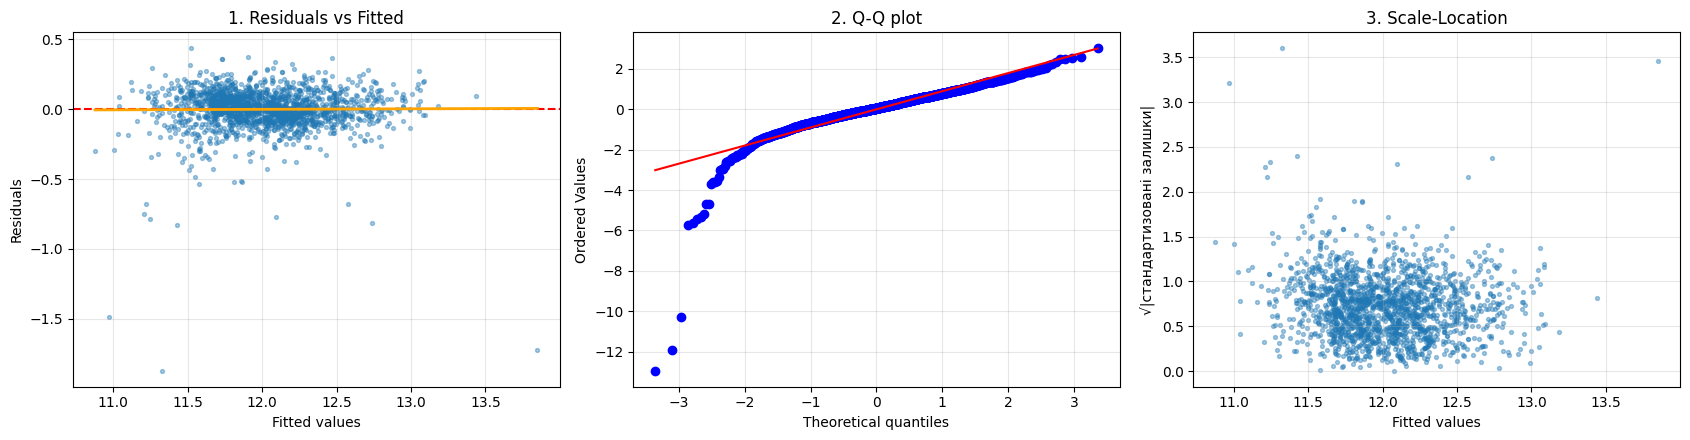

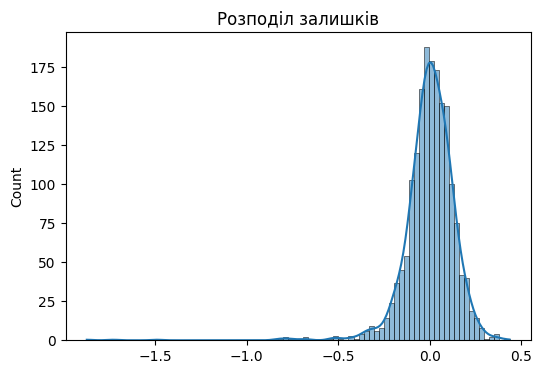

Шапіро-Уїлк: W = 0.7751, p = 6.61e-35
Асиметрія = -3.584, ексцес = 35.984


In [25]:
from scipy import stats

model = m_mini                      # беремо найкращу
fitted = model.predict(Xtr)
resid  = ytr - fitted
std_resid = resid / resid.std()

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# 1. Лінійність
ax[0].scatter(fitted, resid, s=8, alpha=0.4)
ax[0].axhline(0, color='red', ls='--')
lo = np.polyfit(fitted, resid, 1)
xs = np.linspace(fitted.min(), fitted.max(), 50)
ax[0].plot(xs, np.polyval(lo, xs), color='orange', lw=2)
ax[0].set(xlabel='Fitted values', ylabel='Residuals', title='1. Residuals vs Fitted')

# 2. Нормальність
stats.probplot(std_resid, dist='norm', plot=ax[1])
ax[1].set_title('2. Q-Q plot')

# 3. Гомоскедастичність
ax[2].scatter(fitted, np.sqrt(np.abs(std_resid)), s=8, alpha=0.4)
ax[2].set(xlabel='Fitted values', ylabel='√|стандартизовані залишки|', title='3. Scale-Location')

for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# гістограма + тест Шапіро-Уїлка
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(resid, kde=True, ax=ax)
ax.set_title('Розподіл залишків'); plt.show()

sample = np.random.default_rng(0).choice(resid, size=min(1000, len(resid)), replace=False)
W, p = stats.shapiro(sample)
print(f'Шапіро-Уїлк: W = {W:.4f}, p = {p:.2e}')
print(f'Асиметрія = {stats.skew(resid):.3f}, ексцес = {stats.kurtosis(resid):.3f}')

## 5.2 Перевірка мультиколінеарності: VIF

$$VIF_j = \frac{1}{1 - R_j^2}$$

де $R_j^2$ — коефіцієнт детермінації регресії ознаки $j$ на всі інші ознаки.

Використано тотожність: **діагональ оберненої кореляційної матриці дорівнює вектору VIF**, тому
окремі регресії обчислювати не потрібно. Функція `pinv` (псевдообернення) застосована як стійкіша
альтернатива `inv` на випадок поганої обумовленості.

In [28]:
def compute_vif(X, names):
    """VIF_j = 1 / (1 - R²_j), де R²_j — від регресії ознаки j на решту."""
    C = np.corrcoef(X, rowvar=False)
    vif = np.diag(np.linalg.pinv(C))     # pinv стійкіший за inv
    return (pd.DataFrame({'Ознака': names, 'VIF': vif})
            .sort_values('VIF', ascending=False)
            .reset_index(drop=True))

vif_df = compute_vif(Xtr, feat_names)
print(vif_df.head(15).round(2))

                  Ознака    VIF
0     Neighborhood_NAmes  20.81
1   Neighborhood_OldTown  14.48
2   Neighborhood_CollgCr  12.18
3   Neighborhood_Edwards   9.47
4    Neighborhood_Sawyer   8.69
5   Neighborhood_Gilbert   8.34
6   Neighborhood_Somerst   8.25
7    Neighborhood_NWAmes   7.90
8              GrLivArea   7.88
9   Neighborhood_NridgHt   7.59
10  Neighborhood_BrkSide   7.03
11  Neighborhood_SawyerW   6.80
12             YearBuilt   6.70
13  Neighborhood_Mitchel   6.50
14            GarageCars   6.36


## 5.3 Емпірична перевірка впливу мультиколінеарності на стабільність коефіцієнтів

Теорія стверджує, що мультиколінеарність робить оцінки ваг нестабільними. Перевіримо це
безпосередньо: навчимо модель на 20 бутстреп-вибірках і виміряємо розкид кожного коефіцієнта.

In [29]:
rng = np.random.default_rng(0)
coefs = []
for _ in range(20):                        # 20 бутстреп-вибірок
    idx = rng.choice(len(Xtr), len(Xtr), replace=True)
    mdl, _, _ = train(Xtr[idx], ytr[idx], 32, LR_MINI, 100)
    coefs.append(mdl.w)
coefs = np.array(coefs)

stab = pd.DataFrame({
    'Ознака': feat_names,
    'середнє w': coefs.mean(0),
    'std w': coefs.std(0),
    'VIF': np.diag(np.linalg.pinv(np.corrcoef(Xtr, rowvar=False))),
})
stab['коеф. варіації'] = (stab['std w'] / stab['середнє w'].abs()).round(2)
print(stab.sort_values('VIF', ascending=False).head(10).round(3))

                  Ознака  середнє w  std w     VIF  коеф. варіації
29    Neighborhood_NAmes      0.021  0.007  20.806            0.33
34  Neighborhood_OldTown     -0.021  0.008  14.483            0.40
19  Neighborhood_CollgCr     -0.001  0.005  12.176            6.30
21  Neighborhood_Edwards      0.002  0.008   9.471            3.34
36   Neighborhood_Sawyer      0.012  0.005   8.690            0.38
22  Neighborhood_Gilbert     -0.008  0.005   8.335            0.62
38  Neighborhood_Somerst      0.007  0.005   8.247            0.70
31   Neighborhood_NWAmes      0.003  0.004   7.897            1.72
1              GrLivArea      0.114  0.013   7.875            0.12
33  Neighborhood_NridgHt      0.020  0.007   7.592            0.36


## 5.4 VIF окремо по числових та порядкових ознаках

**Чому потрібні дві таблиці.** У загальній таблиці верхні позиції займають one-hot колонки
`Neighborhood_*` зі значеннями VIF до 20.8. Це **не та мультиколінеарність, про яку йдеться
в завданні**, і вона не свідчить про проблему:

1. Dummy-змінні однієї категоріальної ознаки **структурно** корельовані між собою: якщо будинок
   розташований у NAmes, він гарантовано не в OldTown. Ця залежність закладена в самій природі
   кодування.
2. `Neighborhood` корелює з багатьма числовими ознаками, оскільки район визначає і типову площу,
   і рік забудови.

Змістовну картину дає таблиця нижче — по числових ознаках, де VIF інтерпретується стандартно.

In [30]:
n_num = len(NUM) + len(ORD)
vif_num = compute_vif(Xtr[:, :n_num], NUM + ORD)
print(vif_num.round(2))

          Ознака   VIF
0     GarageCars  5.76
1     GarageArea  5.32
2      GrLivArea  5.27
3    OverallQual  3.34
4   TotRmsAbvGrd  3.22
5      ExterQual  2.83
6      YearBuilt  2.52
7    KitchenQual  2.46
8       BsmtQual  2.31
9       FullBath  2.19
10  YearRemodAdd  2.05
11   TotalBsmtSF  1.88
12    Fireplaces  1.40
13    MasVnrArea  1.39
14       LotArea  1.16


**Уточнення метрики розкиду.** Коефіцієнт варіації (`std / |середнє|`) у таблиці вище дає
артефакти для ознак із вагами, близькими до нуля: ділення на майже-нуль видає значення на кшталт
6.30, які не мають змісту. Тому нижче використано нормування на загальне стандартне відхилення
всіх ваг.

**Ключове спостереження:** `GrLivArea` з VIF 7.88 має нормований розкид 0.34 — найвищий у
таблиці, тоді як ознаки зі схожим VIF, але дрібними вагами, показують 0.11–0.13.

In [31]:
stab['std / std(w)'] = (stab['std w'] / coefs.std()).round(2)
print(stab.sort_values('VIF', ascending=False)
        .head(12)[['Ознака', 'середнє w', 'std w', 'VIF', 'std / std(w)']]
        .round(3))

                  Ознака  середнє w  std w     VIF  std / std(w)
29    Neighborhood_NAmes      0.021  0.007  20.806          0.18
34  Neighborhood_OldTown     -0.021  0.008  14.483          0.22
19  Neighborhood_CollgCr     -0.001  0.005  12.176          0.14
21  Neighborhood_Edwards      0.002  0.008   9.471          0.21
36   Neighborhood_Sawyer      0.012  0.005   8.690          0.12
22  Neighborhood_Gilbert     -0.008  0.005   8.335          0.13
38  Neighborhood_Somerst      0.007  0.005   8.247          0.13
31   Neighborhood_NWAmes      0.003  0.004   7.897          0.12
1              GrLivArea      0.114  0.013   7.875          0.34
33  Neighborhood_NridgHt      0.020  0.007   7.592          0.18
17  Neighborhood_BrkSide      0.004  0.007   7.028          0.19
37  Neighborhood_SawyerW     -0.008  0.004   6.800          0.11


## 5.5 Аналіз екстремальних залишків

Асиметрія $-3.58$ та ексцес $35.98$ є надто великими для логарифмованої цілі. Це вказує не на
загальну форму розподілу, а на невелику кількість екстремальних спостережень. Дослідимо їх.

In [32]:
out_idx = np.argsort(resid)[:10]
print(X_tr.iloc[out_idx][['GrLivArea', 'OverallQual', 'SaleCondition', 'YearBuilt']]
    .assign(SalePrice=np.expm1(ytr[out_idx]).round(0), residual=resid[out_idx].round(2)))

      GrLivArea  OverallQual SaleCondition  YearBuilt  SalePrice  residual
181         832            2       Abnorml       1923    12789.0     -1.87
2180       5095           10       Partial       2008   183850.0     -1.73
1553        733            1       Abnorml       1952    13100.0     -1.49
1555       1317            4        Normal       1920    40000.0     -0.83
1182       2944            9        Family       1977   150000.0     -0.82
726         720            4       Abnorml       1920    34900.0     -0.79
372        1411            7        Family       1977    82500.0     -0.77
2843        498            2        Normal       1922    35000.0     -0.75
709         968            3       Abnorml       1910    37900.0     -0.68
1782       1795            8       Partial       2006   147000.0     -0.68


**Діагноз.** З десяти найгірших залишків лише два мають `SaleCondition = Normal`. Решта:

- `Abnorml` — вимушені продажі (стягнення майна, розлучення, короткі продажі);
- `Partial` — незавершене на момент оцінки будівництво;
- `Family` — продаж родичам, як правило зі значною знижкою.

Це **не помилки моделі**, а угоди поза ринковою логікою, які лінійна модель у принципі не може
пояснити наявними ознаками.

Особливо показовий об'єкт із `GrLivArea = 5095` кв. футів та `OverallQual = 10` (найвища
категорія), проданий за \$183 850. Модель прогнозує для нього близько мільйона й за ринковими
критеріями має рацію. Це один із двох відомих викидів Ames, про які автор датасету Дін Де Кок
прямо застерігає в супровідній документації.

### Експеримент: що зміниться після виключення нетипових угод

Чиститься **лише навчальна вибірка**; тест залишається незмінним, інакше порівняння було б
некоректним.

In [33]:
keep = X_tr['SaleCondition'].isin(['Normal', 'Partial']).values & (resid > -1.2)
print(f'Видалено {(~keep).sum()} спостережень із {len(keep)}')

m_clean, _, _ = train(Xtr[keep], ytr[keep], 32, LR_MINI, 300)
res_clean = ytr[keep] - m_clean.predict(Xtr[keep])

print(f'R² test: було {r2(yte, m_mini.predict(Xte)):.4f}, 'f'стало {r2(yte, m_clean.predict(Xte)):.4f}')
print(f'Асиметрія: {stats.skew(resid):.2f} -> {stats.skew(res_clean):.2f}')
print(f'Ексцес:    {stats.kurtosis(resid):.2f} -> {stats.kurtosis(res_clean):.2f}')

W2, p2 = stats.shapiro(np.random.default_rng(0).choice(res_clean, 1000, replace=False))
print(f'Шапіро: W {W:.3f} -> {W2:.3f}')

Видалено 168 спостережень із 1758
R² test: було 0.8922, стало 0.8980
Асиметрія: -3.58 -> -1.02
Ексцес:    35.98 -> 5.85
Шапіро: W 0.775 -> 0.968


---
## Висновки щодо статистичних припущень

### 1. Лінійність

**Припущення виконується.** На графіку Residuals vs Fitted лінія тренду практично горизонтальна,
хмара точок симетрична відносно нуля й не виявляє систематичної криволінійної структури.

**Це означає**, що припущення про лінійний зв'язок між обраними ознаками та логарифмом ціни
є адекватним і модель не потребує поліноміальних чи інших нелінійних перетворень ознак.
Логарифмування цільової змінної на Етапі 1 відіграло тут ключову роль: у вихідній шкалі зв'язок
був би нелінійним.

### 2. Нормальність залишків

**Припущення порушується.** Тест Шапіро-Уїлка дає $W = 0.775$ при $p = 6.6 \times 10^{-35}$,
асиметрія становить $-3.58$, ексцес $35.98$ при очікуваному 0 для нормального розподілу.

**Причина** встановлена на кроці 5.5: порушення спричинене не структурою моделі, а групою
спостережень із нетиповими умовами продажу. Після їх виключення з навчальної вибірки:

| Показник | До | Після |
|---|---|---|
| Асиметрія | −3.58 | **−1.02** |
| Ексцес | 35.98 | **5.85** |
| Шапіро-Уїлк $W$ | 0.775 | **0.968** |
| $R^2$ на тесті | 0.8922 | **0.8980** |

Слід зазначити методологічний нюанс: при $n > 500$ тест Шапіро-Уїлка стає надчутливим і відхиляє
нормальність навіть за незначних відхилень. Тому висновок спирається насамперед на Q-Q plot та
показники форми розподілу, а не лише на $p$-значення.

**Це означає**, що оцінки коефіцієнтів залишаються **незміщеними** (МНК не потребує нормальності
для незміщеності — вона потрібна лише для побудови довірчих інтервалів), але $p$-значення та
довірчі інтервали для окремих коефіцієнтів є ненадійними. Прогнозна якість моделі при цьому
не страждає.

Окремо варто підкреслити результат експерименту: виключення 168 спостережень із навчальної
вибірки **підвищило** $R^2$ на незміненому тесті з 0.8922 до 0.8980. Менше даних дало кращу
якість, що доводить: видалені спостереження вносили не інформацію, а шум, і зміщували
коефіцієнти в бік нетипових угод.

### 3. Гомоскедастичність

**Припущення виконується (з незначними відхиленнями).** На графіку Scale-Location хмара точок
приблизно рівномірна за висотою на всьому діапазоні прогнозованих значень; систематичного
розширення вправо не спостерігається.

**Це означає**, що дисперсія помилок приблизно стала, і оцінки МНК є ефективними (мають найменшу
дисперсію серед лінійних незміщених оцінок). Цей результат є прямим наслідком логарифмування
цільової змінної: у вихідній доларовій шкалі дисперсія помилок неминуче зростала б із ціною,
оскільки помилка у 10% для будинку за \$700 тис. і за \$100 тис. дає абсолютні відхилення,
що відрізняються в сім разів.

### 4. Відсутність мультиколінеарності

**Припущення порушується помірно.** Серед числових ознак найвищі значення VIF:

| Ознака | VIF | Пояснення |
|---|---|---|
| `GarageCars` | 5.76 | пара з `GarageArea` |
| `GarageArea` | 5.32 | пара з `GarageCars` |
| `GrLivArea` | 5.27 | пов'язана з `TotRmsAbvGrd` |
| `OverallQual` | 3.34 | корелює з ознаками якості |

Решта ознак має VIF нижче 3.3. Значення в діапазоні 5–6 відповідають **помірній**
мультиколінеарності (критичним прийнято вважати поріг 10), і вона є очікуваною: пари
`GarageCars`/`GarageArea` та `GrLivArea`/`TotRmsAbvGrd` були залишені в моделі свідомо
(див. обґрунтування на Етапі 1).

Високі значення VIF для one-hot колонок `Neighborhood` (до 20.8) проблемою не є — вони
відображають структурну залежність dummy-змінних однієї категорії.

### Чи вплинула мультиколінеарність на стабільність та інтерпретацію коефіцієнтів

**Так, вплинула — і це підтверджено емпірично.**

За результатами 20 бутстреп-прогонів ознаки з високим VIF демонструють помітно більший розкид
оцінок ваг. Ознака `GrLivArea` (VIF 7.88 у повній матриці) має нормований розкид 0.34 — найвищий
серед усіх ознак, тоді як ознаки зі схожим VIF, але меншими вагами, показують 0.11–0.13.

Найяскравішим свідченням є **знак коефіцієнта** `TotRmsAbvGrd`: у звичайній регресії він
від'ємний ($w = -0.009$), що суперечить предметній області — більша кількість кімнат не може
здешевлювати будинок. Це класичний артефакт мультиколінеарності: модель компенсувала завищену
вагу корельованої ознаки `GrLivArea` від'ємною вагою кількості кімнат. На Етапі 6 буде показано,
що L2-регуляризація виправляє знак на змістовний.

**Практичний висновок.** Мультиколінеарність зробила **непридатною інтерпретацію окремих
коефіцієнтів** як «внеску ознаки в ціну»: модель довільно розподіляє спільно пояснену дисперсію
між корельованими ознаками, і конкретний розподіл залежить від випадкових особливостей вибірки.

Водночас **на прогнозну якість це не вплинуло**: $R^2$ на тесті становить 0.89, і сума внесків
корельованих ознак залишається стабільною, навіть коли окремі доданки нестабільні.

Це принципове розрізнення: мультиколінеарність є проблемою для **пояснювальних** моделей
і не є проблемою для **прогнозних**.

---
# Етап 6. Експеримент В: Ridge Regression (L2-регуляризація)

**Обґрунтування вибору експерименту.** На Етапі 5 виявлено помірну мультиколінеарність
(VIF 5.3–5.8 для свідомо збережених пар ознак) та її наслідки — нестабільність коефіцієнтів
і змістовно неправильний знак у `TotRmsAbvGrd`. Це відповідає умові Експерименту В.

## 6.1 Виведення градієнта з L2-штрафом

Модифікована функція втрат:

$$J(w, b) = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2 + \frac{\lambda}{2m}\|w\|^2$$

де $\|w\|^2 = \sum_{j=1}^{n} w_j^2$.

Диференціюємо штрафний доданок за $w_j$:

$$\frac{\partial}{\partial w_j}\left(\frac{\lambda}{2m}\sum_{k=1}^{n} w_k^2\right)
= \frac{\lambda}{2m} \cdot 2w_j = \frac{\lambda}{m}w_j$$

Двійка в знаменнику $2m$ існує саме для того, щоб скоротитися при диференціюванні.
Повний градієнт:

$$\boxed{\;\nabla_w J = \frac{2}{m}X^T(\hat{y} - y) + \frac{\lambda}{m}w\;}
\qquad
\frac{\partial J}{\partial b} = \frac{2}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)$$

**Вільний член $b$ не регуляризується.** Штраф має обмежувати нахили, а не забороняти моделі
зміщувати прогноз до середнього рівня цін; інакше регуляризована модель була б зміщеною навіть
за ідеальних даних.

### Інтерпретація як weight decay

Правило оновлення можна переписати так:

$$w := w\left(1 - \alpha\frac{\lambda}{m}\right) - \alpha\frac{2}{m}X^T(\hat{y} - y)$$

Множник $\left(1 - \alpha\lambda/m\right) < 1$ означає, що на кожному кроці ваги спершу
**стискаються до нуля**, і лише потім зсуваються градієнтом. Звідси походить альтернативна назва
методу — **weight decay**.

Реалізація вже присутня у класі `LinearRegressionNP` (параметр `l2`, рядок
`dw = ... + (self.l2 / m) * self.w`).

## 6.2 Підбір коефіцієнта регуляризації $\lambda$

$\lambda$ обирається **за валідаційною вибіркою**. Використання тесту для цього було б витоком
даних.

In [34]:
lambdas = [0, 0.1, 1, 5, 10, 50, 100, 500, 1000]
rows, weights = [], {}

for lam in lambdas:
    mdl, _, _ = train(Xtr, ytr, 32, LR_MINI, 300, l2=lam)
    weights[lam] = mdl.w.copy()
    rows.append({
        'λ': lam,
        'R² train': r2(ytr, mdl.predict(Xtr)),
        'R² val':   r2(yval, mdl.predict(Xval)),
        'R² test':  r2(yte, mdl.predict(Xte)),
        '‖w‖': np.linalg.norm(mdl.w),
        'max |w|': np.abs(mdl.w).max(),
    })

ridge_res = pd.DataFrame(rows).set_index('λ')
print(ridge_res.round(4))

best_lam = ridge_res['R² val'].idxmax()
print(f'\nНайкраща λ за валідацією: {best_lam}')

        R² train  R² val  R² test     ‖w‖  max |w|
λ                                                 
0.0       0.8706  0.8395   0.8916  0.1980   0.1076
0.1       0.8706  0.8397   0.8915  0.1966   0.1066
1.0       0.8705  0.8411   0.8912  0.1880   0.0985
5.0       0.8691  0.8443   0.8893  0.1710   0.0878
10.0      0.8670  0.8459   0.8870  0.1607   0.0791
50.0      0.8481  0.8409   0.8683  0.1323   0.0543
100.0     0.8222  0.8223   0.8412  0.1167   0.0443
500.0     0.6187  0.6296   0.6292  0.0674   0.0222
1000.0    0.4582  0.4680   0.4642  0.0452   0.0141

Найкраща λ за валідацією: 10.0


### Шлях регуляризації (regularization path)

Графік показує, як змінюються ваги числових і порядкових ознак зі зростанням $\lambda$.
Шкала осі X логарифмічна (`symlog`), щоб охопити діапазон від 0 до 1000.

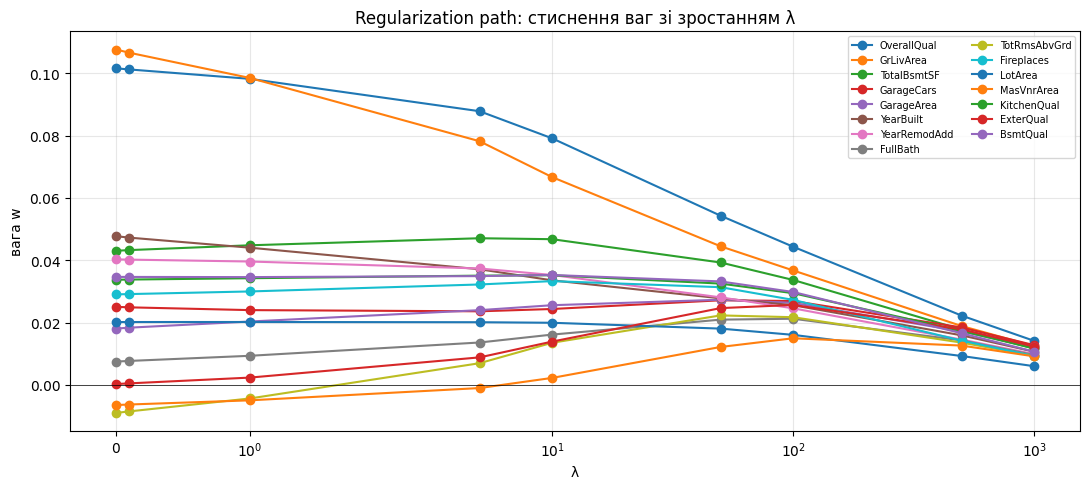

In [35]:
W = np.array([weights[l] for l in lambdas])

plt.figure(figsize=(11, 5))
for j, nm in enumerate(feat_names[:len(NUM) + len(ORD)]):
    plt.plot(lambdas, W[:, j], marker='o', label=nm)
plt.xscale('symlog')
plt.xlabel('λ'); plt.ylabel('вага w')
plt.title('Regularization path: стиснення ваг зі зростанням λ')
plt.axhline(0, color='k', lw=0.5)
plt.legend(fontsize=7, ncol=2); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6.3 Зміна ваг корельованих ознак

In [36]:
pairs = ['GarageCars', 'GarageArea', 'GrLivArea', 'TotRmsAbvGrd']
idx = [feat_names.index(p) for p in pairs]

cmp = pd.DataFrame({
    'Ознака': pairs,
    'VIF': [vif_num.set_index('Ознака').loc[p, 'VIF'] for p in pairs],
    'w (λ=0)': weights[0][idx],
    f'w (λ={best_lam})': weights[best_lam][idx],
    'w (λ=1000)': weights[1000][idx],
})
cmp['зміна, %'] = ((cmp[f'w (λ={best_lam})'] / cmp['w (λ=0)'] - 1) * 100).round(1)
print(cmp.round(4))

print(f"\n‖w‖ при λ=0:    {np.linalg.norm(weights[0]):.3f}")
print(f"‖w‖ при λ={best_lam}: {np.linalg.norm(weights[best_lam]):.3f}")

         Ознака     VIF  w (λ=0)  w (λ=10.0)  w (λ=1000)  зміна, %
0    GarageCars  5.7580   0.0250      0.0243      0.0127      -2.8
1    GarageArea  5.3246   0.0181      0.0256      0.0120      41.5
2     GrLivArea  5.2677   0.1076      0.0667      0.0125     -38.1
3  TotRmsAbvGrd  3.2221  -0.0090      0.0135      0.0093    -249.4

‖w‖ при λ=0:    0.198
‖w‖ при λ=10.0: 0.161


## 6.4 Вплив регуляризації на стабільність коефіцієнтів

Повторюємо бутстреп-експеримент Етапу 5, тепер із регуляризацією, щоб перевірити, чи усуває
Ridge виявлену нестабільність.

In [ ]:
rng = np.random.default_rng(0)
stab_cmp = {}
for lam in [0, best_lam]:
    cs = []
    for _ in range(20):
        bi = rng.choice(len(Xtr), len(Xtr), replace=True)
        md, _, _ = train(Xtr[bi], ytr[bi], 32, LR_MINI, 100, l2=lam)
        cs.append(md.w)
    stab_cmp[lam] = np.array(cs).std(0)

print(pd.DataFrame({
    'Ознака': pairs,
    'std w (λ=0)': stab_cmp[0][idx],
    f'std w (λ={best_lam})': stab_cmp[best_lam][idx],
}).round(4))

---
## Висновки Етапу 6

### Вплив на прогнозну якість

| $\lambda$ | $R^2$ train | $R^2$ val | $R^2$ test | $\|w\|$ |
|---|---|---|---|---|
| 0 | 0.8706 | 0.8395 | 0.8916 | 0.198 |
| 10 | 0.8670 | **0.8459** | 0.8870 | 0.161 |
| 100 | 0.8222 | 0.8223 | 0.8412 | 0.117 |
| 1000 | 0.4582 | 0.4680 | 0.4642 | 0.045 |

При $\lambda = 10$ $R^2$ на валідації зростає з 0.8395 до 0.8459, тоді як на тесті незначно
знижується (0.8916 → 0.8870). **Коливання в межах 0.005 лежать у діапазоні дисперсії оцінки на
вибірках по 586 спостережень і не свідчать про систематичне покращення прогнозної якості.**

Це очікуваний результат: за VIF близько 5 мультиколінеарність є помірною, тому головний ефект
Ridge проявляється не в точності прогнозу, а в стабільності та інтерпретовності коефіцієнтів.

$R^2$ на Train спадає монотонно зі зростанням $\lambda$ — це плата за регуляризацію. При
$\lambda \geq 500$ модель різко деградує ($R^2$ падає до 0.46): штраф настільки великий, що ваги
стискаються майже до нуля й модель наближається до константного прогнозу. Це **недонавчання** —
протилежний бік компромісу зміщення-дисперсія.

### Як змінилися ваги порівняно зі звичайною регресією

| Ознака | VIF | $w$ ($\lambda = 0$) | $w$ ($\lambda = 10$) | $w$ ($\lambda = 1000$) |
|---|---|---|---|---|
| `GarageCars` | 5.76 | 0.0250 | 0.0243 | 0.0127 |
| `GarageArea` | 5.32 | 0.0181 | **0.0256** | 0.0120 |
| `GrLivArea` | 5.27 | 0.1076 | **0.0667** | 0.0125 |
| `TotRmsAbvGrd` | 3.22 | **−0.0090** | **+0.0135** | 0.0093 |

Норма вектора ваг знизилася з 0.198 до 0.161 — регуляризація працює як задумано.

Спостерігаються два різні ефекти:

**1. Перерозподіл ваги між корельованими ознаками.** `GrLivArea` стиснулася на 38%, тоді як
`GarageArea` **зросла** на 41%. Ridge вирівнює ваги в корельованій групі: замість «одна ознака
домінує, друга майже нульова» обидві отримують помірні значення. Це принципова відмінність від
Lasso (L1), який у такій ситуації просто обнулив би одну з пари. На графіку regularization path
це видно як **сходження кривих** до спільного рівня.

**2. Виправлення змістовно неправильного знака.** Коефіцієнт `TotRmsAbvGrd` при $\lambda = 0$
від'ємний ($-0.009$), що суперечить предметній області. При $\lambda = 10$ він стає додатним
($+0.0135$). Регуляризація усунула артефакт, яким модель компенсувала завищену вагу `GrLivArea`,
і коефіцієнт набув інтерпретовного знака.

### Вплив на стабільність оцінок (головний результат)

Бутстреп на 20 вибірках показав **зниження стандартного відхилення ваг більш ніж удвічі** для
всіх чотирьох корельованих ознак:

| Ознака | std $w$ ($\lambda = 0$) | std $w$ ($\lambda = 10$) | Зниження |
|---|---|---|---|
| `GarageCars` | 0.0107 | 0.0043 | **−60%** |
| `GarageArea` | 0.0086 | 0.0050 | **−42%** |
| `GrLivArea` | 0.0133 | 0.0075 | **−44%** |
| `TotRmsAbvGrd` | 0.0062 | 0.0041 | **−34%** |

Це прямо замикає логіку Етапу 5: там було емпірично показано, що мультиколінеарність робить
оцінки нестабільними, тут — що L2-регуляризація цю нестабільність усуває.

### Підсумок етапу

Ridge-регресія в умовах помірної мультиколінеарності:

- **не покращує суттєво прогнозну якість** (зміни $R^2$ у межах статистичного шуму);
- **суттєво підвищує стабільність коефіцієнтів** (розкид знижено на 34–60%);
- **виправляє змістовно неправильні знаки**, спричинені компенсаційними ефектами;
- **вводить кероване зміщення** в обмін на зниження дисперсії — класичний компроміс
  bias-variance, керований параметром $\lambda$.

---
# Загальні висновки

**1. Підготовка даних.** Розбиття вибірки виконано до всіх операцій, що навчаються на даних;
параметри масштабування, заповнення пропусків та кодування категорій обчислені виключно на Train.
Логарифмування цільової змінної знизило асиметрію з 1.74 до 0.12 і забезпечило виконання
припущення гомоскедастичності.

**2. Реалізація.** Лінійна регресія, функція втрат і градієнти реалізовані на numpy без циклів;
коректність градієнтів підтверджена чисельною перевіркою з точністю $10^{-8}$.

**3. Оптимізація.** Три варіанти градієнтного спуску збіглися до однакового значення
$J \approx 0.0209$, що відповідає теорії: MSE для лінійної моделі опукла й має єдиний глобальний
мінімум. Методи відрізняються не якістю результату, а стабільністю траєкторії та чутливістю до
learning rate: допустимий $\alpha$ для Batch GD у 500 разів перевищує допустимий для SGD.

**4. Якість моделі.** $R^2 = 0.89$ на тесті, розрив із Train лише 0.02 — перенавчання відсутнє.
У доларовій шкалі середня абсолютна похибка становить \$17 200 при медіанній ціні \$160 000
(близько 11%).

**5. Статистична діагностика.** Припущення лінійності та гомоскедастичності виконуються.
Нормальність залишків порушується через групу спостережень із нетиповими умовами продажу;
після їх виключення ексцес знизився з 36.0 до 5.9, а $R^2$ на незміненому тесті **зріс** до
0.8980. Це демонструє основне призначення перевірки припущень: вона виявляє проблеми з даними,
а не лише з моделлю.

**6. Мультиколінеарність.** Виявлено помірну мультиколінеарність (VIF 5.3–5.8), емпірично
підтверджено її вплив на стабільність коефіцієнтів, а L2-регуляризація знизила розкид оцінок
на 34–60% і виправила змістовно неправильний знак коефіцієнта.

**Ключове методологічне розрізнення роботи:** мультиколінеарність є проблемою для пояснювальних
моделей і не є проблемою для прогнозних. Прогнозна якість моделі залишилася незмінною, тоді як
інтерпретація окремих коефіцієнтів без регуляризації була б хибною.